[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/su-ntu-ctp/6m-data-3.8-Computer-Vision/blob/main/notebooks/01_monday_morning.ipynb)

# L08 · NB 01 — Monday morning: tagging product photos

> *Marcus's request, fresh out of Friday's stand-up: "Can we auto-tag product photos as dress, shirt, sneaker? We have ~10,000 new uploads each season."*

Sarah's first move is the simplest one she already knows: **flatten the images and train an MLP**. It's the same playbook she just used in L07. Does it work?

This notebook is pre-class. Run it before class so you walk in with an honest baseline number — and a sense of why we're going to need something better.

## 1 · Setup

In [1]:
# SETUP: load all the tools we'll need and make results repeatable.
# NumPy = number crunching, Matplotlib = drawing pictures/charts,
# PyTorch (torch) = the deep-learning library we use to build and train models.

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn                      # nn = neural-network building blocks (layers, etc.)
import torchvision                          # torchvision = image datasets + models for vision
import torchvision.transforms as T          # transforms = ways to prep images (resize, to-tensor, ...)
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader     # DataLoader feeds data to the model in batches

torch.set_num_threads(1)   # limit CPU threads so timing/results are steady across machines
# Setting a fixed random "seed" means the same random numbers every run,
# so you and your classmates get identical, reproducible results.
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cpu"   # run on the CPU (no GPU needed for this small example)
print("Torch:", torch.__version__, "| device:", DEVICE)

Torch: 2.12.0+cu130 | device: cpu


## 2 · Load Fashion-MNIST

Fashion-MNIST is a drop-in replacement for the classic MNIST digits — 70K 28×28 grayscale images of 10 apparel categories. Convenient stand-in for Marcus's catalogue.

In [2]:
# LOAD THE DATA: download the Fashion-MNIST image dataset and inspect its shape.
# A "tensor" is just a multi-dimensional array of numbers — how PyTorch stores images.

transform = T.Compose([T.ToTensor()])  # converts to (C, H, W) float tensors in [0, 1]
DATA_ROOT = "data/fmnist"               # folder where the downloaded images are stored

# train_ds = images used to TEACH the model; test_ds = unseen images used to GRADE it.
# download=True fetches the data the first time; transform applies the conversion above.
train_ds = FashionMNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
test_ds  = FashionMNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

CLASSES = train_ds.classes              # the 10 category names (T-shirt, Trouser, ...)
print(f"Train size : {len(train_ds):,}")
print(f"Test size  : {len(test_ds):,}")
print(f"Classes    : {CLASSES}")
# Each image is 1 channel (grayscale), 28 pixels tall, 28 pixels wide.
print(f"Image shape: {train_ds[0][0].shape}  # (channels, height, width)")

Train size : 60,000
Test size  : 10,000
Classes    : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Image shape: torch.Size([1, 28, 28])  # (channels, height, width)


## 3 · Eyeball the data

Never model what you haven't looked at.

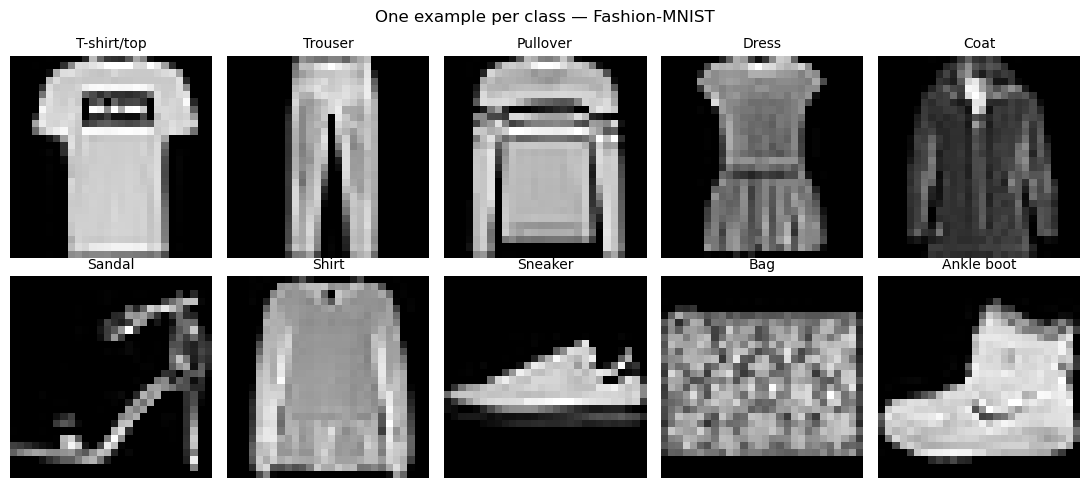

In [3]:
# EYEBALL THE DATA: show one example image from each of the 10 clothing classes
# so we can see what the model is up against before training anything.

fig, axes = plt.subplots(2, 5, figsize=(11, 5))   # a grid of 2 rows x 5 columns = 10 slots
for ax, cls_idx in zip(axes.flat, range(10)):
    # find one example of each class
    # scan through the dataset and grab the first image whose label (y) matches this class
    idx = next(i for i, (_, y) in enumerate(train_ds) if y == cls_idx)
    img, _ = train_ds[idx]
    ax.imshow(img.squeeze(), cmap='gray')   # squeeze() drops the channel dim so it draws as 2D; gray = grayscale
    ax.set_title(CLASSES[cls_idx], fontsize=10)
    ax.axis('off')                          # hide the x/y axis ticks — we just want the picture
plt.suptitle("One example per class — Fashion-MNIST", fontsize=12)
plt.tight_layout()                          # nicely space the subplots
plt.show()

Stop and stare. Some of these are easy (sandals look very different from coats), but **shirt vs T-shirt/top vs pullover** is hard even for a human at thumbnail size. Keep that in mind when we evaluate accuracy in a minute.

## 4 · Flatten + MLP — the L07 playbook

Flatten each 28×28 image into a 784-dim vector. Then it's just tabular data, and we already know how to train an MLP on tabular data.

In [4]:
# BUILD THE MODEL: define a simple neural network (an "MLP") that treats each image
# as one long list of 784 pixel values and learns to guess which of the 10 classes it is.
# MLP = Multi-Layer Perceptron: stacked layers of neurons, each doing weighted sums.

class FlatMLP(nn.Module):
    """Two-hidden-layer MLP on flattened pixels."""
    def __init__(self, in_dim=784, hidden=256, n_classes=10):
        super().__init__()
        # Sequential = run these layers one after another, top to bottom.
        self.net = nn.Sequential(
            nn.Flatten(),                  # (B, 1, 28, 28) -> (B, 784): squash the 28x28 grid into one row
            nn.Linear(in_dim, hidden),     # Linear = a layer of neurons: weighted sum of all inputs
            nn.ReLU(),                     # ReLU = keep positives, zero out negatives; lets the net learn curves
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_classes),  # final layer: one score per class (10 scores out)
        )
    def forward(self, x):
        # forward() = how an input image flows through the network to produce 10 scores
        return self.net(x)

mlp = FlatMLP()
# Count every weight the model must learn — its "size". More params = more to train.
n_params = sum(p.numel() for p in mlp.parameters())
print(f"FlatMLP parameter count: {n_params:,}")
print(mlp)

FlatMLP parameter count: 235,146
FlatMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


**~235K parameters** for tiny 28×28 images. Now imagine real product photos at 224×224 colour — the first layer alone would need 38 million weights. Tuck that away for later.

---

**Where do these numbers come from?** A `Linear` layer has one weight for every (input × neuron) pair, plus one bias per neuron: `weights = inputs × neurons`, `biases = neurons`.

*The 235K (this model, 28×28 grayscale):* flattening gives `28 × 28 × 1 = 784` inputs, and the three Linear layers are 784→256, 256→128, 128→10:

| Layer | Weights (inputs × neurons) | Biases | Total |
|-------|---------------------------|--------|-------|
| 784 → 256 | 784 × 256 = 200,704 | 256 | 200,960 |
| 256 → 128 | 256 × 128 = 32,768 | 128 | 32,896 |
| 128 → 10  | 128 × 10 = 1,280 | 10 | 1,290 |
| **Sum** | | | **235,146** ✓ |

*The 38 million (real photos, 224×224 colour):* flattening gives `224 × 224 × 3 = 150,528` inputs (×3 for the R, G, B channels). With the same 256-neuron first layer:

```
150,528 inputs × 256 neurons = 38,535,168 weights ≈ 38 million
```

— and that's just the **first layer**. The cost of a fully-connected layer grows with the *total pixel count*, so bigger images blow it up fast. This is exactly why we need CNNs, which reuse one small filter across the whole image instead of one weight per pixel.

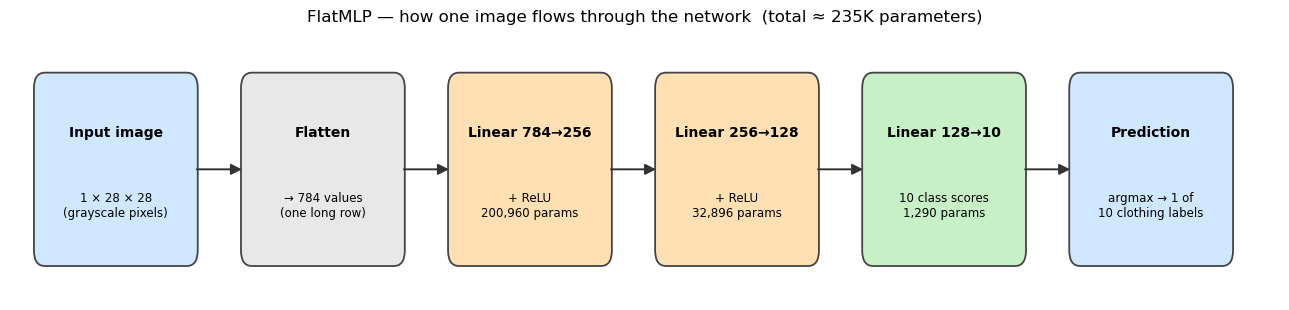

In [5]:
# DRAW THE MODEL: a schematic of how one image flows through the FlatMLP,
# layer by layer, so we can SEE the shape change from a 28x28 grid down to 10 scores.
# (Pure drawing code — it doesn't train anything; it just visualises the architecture above.)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Each block = one stage in the network: (label, detail, colour)
stages = [
    ("Input image",    "1 × 28 × 28\n(grayscale pixels)", "#cfe8ff"),
    ("Flatten",        "→ 784 values\n(one long row)",     "#e8e8e8"),
    ("Linear 784→256", "+ ReLU\n200,960 params",           "#ffe0b3"),
    ("Linear 256→128", "+ ReLU\n32,896 params",            "#ffe0b3"),
    ("Linear 128→10",  "10 class scores\n1,290 params",    "#c7f0c7"),
    ("Prediction",     "argmax → 1 of\n10 clothing labels","#cfe8ff"),
]

fig, ax = plt.subplots(figsize=(13, 3.2))
box_w, box_h, gap = 1.7, 1.4, 0.55   # size of each box and the gap between them
x, centers = 0, []
for label, detail, colour in stages:
    # one rounded rectangle per stage
    ax.add_patch(FancyBboxPatch((x, 0), box_w, box_h,
                 boxstyle="round,pad=0.04,rounding_size=0.12",
                 linewidth=1.3, edgecolor="#444", facecolor=colour))
    cx = x + box_w / 2
    centers.append(cx)
    ax.text(cx, box_h - 0.42, label, ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(cx, 0.42, detail, ha="center", va="center", fontsize=8.5)   # the shape/param detail
    x += box_w + gap

# arrows showing the left-to-right flow from one stage to the next
for i in range(len(stages) - 1):
    ax.add_patch(FancyArrowPatch((centers[i] + box_w/2, box_h/2),
                 (centers[i+1] - box_w/2, box_h/2),
                 arrowstyle="-|>", mutation_scale=16, linewidth=1.4, color="#333"))

ax.set_xlim(-0.3, x); ax.set_ylim(-0.3, box_h + 0.3); ax.axis("off")
ax.set_title("FlatMLP — how one image flows through the network  (total ≈ 235K parameters)",
             fontsize=12, pad=12)
plt.tight_layout()
plt.show()

## 5 · Train the MLP

Standard L07 PyTorch training loop. We'll go 5 epochs — enough to get an honest number, fast enough to stay under a minute.

In [8]:
# TRAIN THE MODEL: repeatedly show it batches of images, let it guess, measure how
# wrong it is, and nudge its weights to do better. Then check accuracy on unseen test images.

BATCH = 256     # how many images the model looks at at once (a "batch")
EPOCHS = 5      # an "epoch" = one full pass over all the training images; we do 5 passes
LR = 1e-3       # learning rate = how big a step we take when adjusting weights (too big overshoots)

# DataLoader hands out the data in batches. shuffle=True mixes the order each epoch
# so the model doesn't memorize the sequence; we don't shuffle the test set.
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

# Adam = the optimizer: the algorithm that actually updates the weights using the gradients.
optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
# CrossEntropyLoss = the "how wrong was the guess?" score for classification tasks.
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    # Measure accuracy: what fraction of images the model labels correctly.
    model.eval()                       # eval mode: turn off training-only behaviors
    correct, total = 0, 0
    with torch.no_grad():              # don't track gradients here — we're only checking, not learning (faster)
        for xb, yb in loader:          # xb = batch of images, yb = their true labels
            logits = model(xb)         # logits = the 10 raw scores the model outputs per image
            preds = logits.argmax(dim=1)   # pick the class with the highest score as the prediction
            correct += (preds == yb).sum().item()   # count how many matched the true label
            total += yb.size(0)
    return correct / total

history = []
for epoch in range(1, EPOCHS + 1):
    mlp.train()                        # train mode: enable learning behaviors
    running = 0.0
    for xb, yb in train_loader:        # loop over every batch in the training set
        optimizer.zero_grad()          # clear leftover gradients from the previous step
        loss = criterion(mlp(xb), yb)  # forward pass: guess, then score how wrong it was
        loss.backward()                # backward(): compute how much each weight contributed to the error (gradients)
        optimizer.step()               # nudge every weight a little in the direction that reduces the error
        running += loss.item() * xb.size(0)   # accumulate loss, weighted by batch size, for a clean average
    train_loss = running / len(train_ds)      # average loss across all training images this epoch
    test_acc = evaluate(mlp, test_loader)      # check accuracy on the unseen test set
    history.append((epoch, train_loss, test_acc))
    print(f"epoch {epoch} | train loss {train_loss:.4f} | test acc {test_acc:.4f}")

epoch 1 | train loss 0.3036 | test acc 0.8779
epoch 2 | train loss 0.2860 | test acc 0.8811
epoch 3 | train loss 0.2748 | test acc 0.8785
epoch 4 | train loss 0.2655 | test acc 0.8819
epoch 5 | train loss 0.2524 | test acc 0.8749


## 6 · How did we do?

In [9]:
# REPORT THE RESULT: print the final test accuracy and turn it into business terms
# (how often it's wrong) so we can judge if this approach is good enough for Marcus.

mlp_acc = evaluate(mlp, test_loader)   # final accuracy on the unseen test images
print(f"FlatMLP final test accuracy: {mlp_acc:.4f}  ({mlp_acc*100:.1f}%)")
# Misclassification rate = the flip side of accuracy: how often it gets a tag wrong.
print(f"Misclassification rate     : {(1 - mlp_acc)*100:.1f}%")
print(f"Total parameters           : {n_params:,}")

FlatMLP final test accuracy: 0.8749  (87.5%)
Misclassification rate     : 12.5%
Total parameters           : 235,146


Around **87% accuracy**. Sounds OK at first. But Marcus said 10,000 new photos per season:

- 13% mis-tag rate → **~1,300 wrong tags every season**
- A merchandiser has to find and fix each one
- Bad tags hurt search relevance and customer trust

We need to do better. And we want to do it without scaling the parameter count linearly with image size.

The fix is to build a model that **knows about images** — that exploits the fact that nearby pixels are related, and that a sleeve is a sleeve wherever it appears.

That model is a **Convolutional Neural Network**. We'll meet it in class.

## 7 · Three thought-questions for class

1. The FlatMLP has ~235K parameters for 28×28 images. How many parameters would the **first layer alone** need for 224×224 colour photos with a 256-neuron hidden layer? Does that scale to real product imaging?
2. Pixel (10, 10) and pixel (10, 11) are right next to each other — almost always related. How does the MLP know that?
3. If we flipped every training image horizontally, would the MLP still recognise them? Why or why not?

Bring your guesses to class. Tomorrow we'll see the answer.